In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

In [23]:
# pilotos nacidos en el Reino Unido
drivers_british = pd.read_csv('/content/drivers_british.csv')
# constructores no británicos
constructors_not_british = pd.read_csv('/content/constructors_no_british.csv')
# Primeros 10 circuitos ordenados
circuits_10 = pd.read_csv('/content/circuits_10.csv')
# pilotos más jóvenes
drivers_odered = pd.read_csv('/content/drivers_odered.csv')
# pilotos que ganaron alguna carrera
drivers_wins = pd.read_csv('/content/drivers_wins.csv')
# número de victorias por piloto
drivers_number_wins = pd.read_csv('/content/drivers_number_wins.csv')
# número total de carreras por circuito
races_per_circuit = pd.read_csv('/content/races_per_circuit.csv')
# nombre completo del piloto, el nombre del constructor y la posición final obtenida en carreras donde la posición fue 1.
drivers_first_place = pd.read_csv('/content/drivers_first_place.csv')
# nombres de los pilotos cuyo número total de victorias (posición = 1) es mayor que el promedio de victorias de todos los pilotos.
results_mean_victory = pd.read_csv('/content/results_mean_victory.csv')
# constructores que han obtenido el mayor número de victorias
constructors_victories = pd.read_csv('/content/constructors_victories.csv')


# Los pilotos nacidos en el Reino Unido

Se muestra una distribución de pilotos británicos en diferentes grupos de edad, revelando patrones generacionales en el automovilismo británico.

A pesar de la diferencia de edad dentro de los pilotos británicos, este grupo solo representa el 10% de todos los pilotos analizados.

In [6]:
drivers_british.head()

,forename,surname,dob,nationality
0,Lewis,Hamilton,1985-01-07,British
1,David,Coulthard,1971-03-27,British
2,Jenson,Button,1980-01-19,British
3,Anthony,Davidson,1979-04-18,British
4,Justin,Wilson,1978-07-31,British


Text(0.5, 1.0, 'Distribución de Pilotos Británicos por Grupos de Edad')

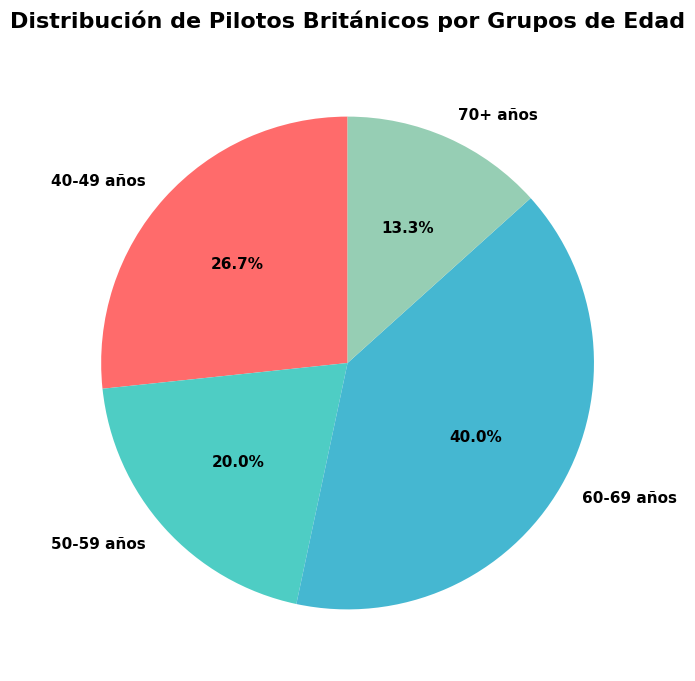

In [82]:
drivers_british['birth_date'] = pd.to_datetime(drivers_british['dob'], errors='coerce')
current_date = datetime.now()
drivers_british['age'] = (current_date - drivers_british['birth_date']).dt.days // 365

def assign_age_group(age):
    if age < 40:
        return '30-39 años'
    elif age < 50:
        return '40-49 años'
    elif age < 60:
        return '50-59 años'
    elif age < 70:
        return '60-69 años'
    else:
        return '70+ años'

drivers_british['age_group'] = drivers_british['age'].apply(assign_age_group)

age_group_counts = drivers_british['age_group'].value_counts().sort_index()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(age_group_counts.values,
                                   labels=age_group_counts.index,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   textprops={'fontsize': 11, 'fontweight': 'bold'})

plt.title('Distribución de Pilotos Británicos por Grupos de Edad',
          fontsize=16, fontweight='bold', pad=20)

# Constructores no británicos

los Americanos e Italianos dominan entre los constructores.

USA (America) construye lo mismo que 18 paises combinados.

In [25]:
constructors_not_british.head()

,name,nationality,constructorRef
0,BMW Sauber,German,bmw_sauber
1,Renault,French,renault
2,Toro Rosso,Italian,toro_rosso
3,Ferrari,Italian,ferrari
4,Toyota,Japanese,toyota
...,...,...,...
121,Caterham,Malaysian,caterham
122,Haas F1 Team,American,haas
123,AlphaTauri,Italian,alphatauri
124,Alpine F1 Team,French,alpine


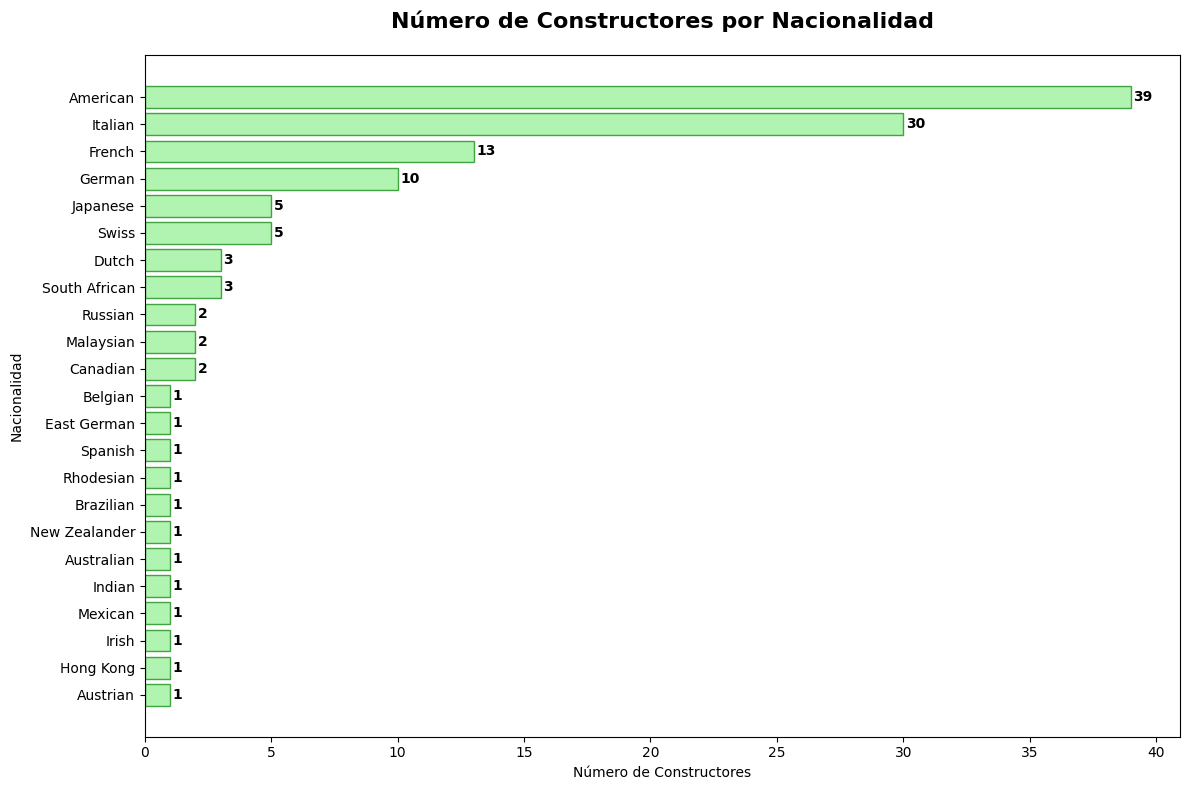

In [28]:
plt.figure(figsize=(12, 8))
nationality_counts = constructors_not_british['nationality'].value_counts()
nationality_counts_sorted = nationality_counts.sort_values(ascending=True)

bars = plt.barh(nationality_counts_sorted.index, nationality_counts_sorted.values,
                color='lightgreen', edgecolor='green', alpha=0.7)

plt.title('Número de Constructores por Nacionalidad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Constructores')
plt.ylabel('Nacionalidad')

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}',
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Primeros 10 circuitos ordenados

Se puede apreciar en los resultados donde se ubican los autodromos y otras locaciones que empiezan por A.

In [36]:
circuits_10.head()

,circuitId,name,location,country
0,29,Adelaide Street Circuit,Adelaide,Australia
1,64,Ain Diab,Casablanca,Morocco
2,58,Aintree,Liverpool,UK
3,1,Albert Park Grand Prix Circuit,Melbourne,Australia
4,27,AutÃ³dromo do Estoril,Estoril,Portugal


# Los pilotos más jóvenes
El piloto mas joven es Sebastien Buemi con 37 años

El piloto mas veterano es Nelson Piquet Sr con 73 años

Entre los pilotos mas jovenes estan los suizos y fanceses

La mayoria de los pilotos son italianos, le sigue belgas y brazileños.

In [42]:
drivers_odered.head()

,forename,surname,dob,nationality
0,SÃ©bastien,Buemi,1988-10-31,Swiss
1,Sebastian,Vettel,1987-07-03,German
2,Nelson,Piquet Jr.,1985-07-25,Brazilian
3,Nico,Rosberg,1985-06-27,German
4,Kazuki,Nakajima,1985-01-11,Japanese


<Figure size 1200x800 with 0 Axes>

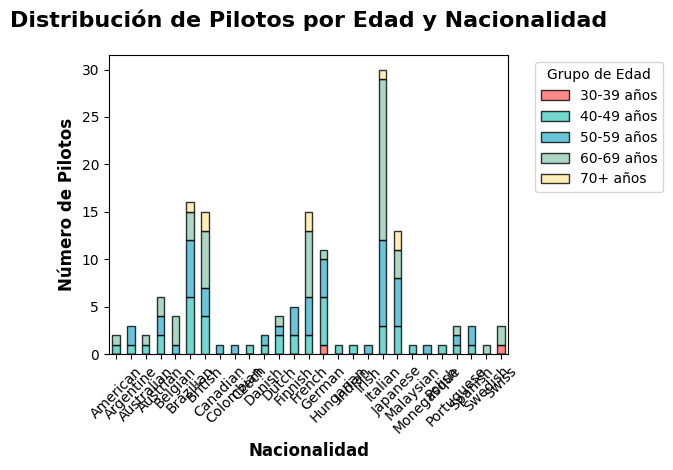

In [52]:
drivers_odered['birth_date'] = pd.to_datetime(drivers_odered['dob'], errors='coerce')
current_date = datetime.now()
drivers_odered['age'] = (current_date - drivers_odered['birth_date']).dt.days // 365
drivers_odered['birth_year'] = drivers_odered['birth_date'].dt.year

def assign_age_group(age):
    if age < 30:
        return '20-29 años'
    elif age < 40:
        return '30-39 años'
    elif age < 50:
        return '40-49 años'
    elif age < 60:
        return '50-59 años'
    elif age < 70:
        return '60-69 años'
    else:
        return '70+ años'

drivers_odered['age_group'] = drivers_odered['age'].apply(assign_age_group)

age_nationality = pd.crosstab(drivers_odered['nationality'], drivers_odered['age_group'])

plt.figure(figsize=(12, 12))
age_nationality.plot(kind='bar', stacked=True,
                     color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'],
                     edgecolor='black', alpha=0.8)

plt.title('Distribución de Pilotos por Edad y Nacionalidad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nacionalidad', fontsize=12, fontweight='bold')
plt.ylabel('Número de Pilotos', fontsize=12, fontweight='bold')
plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Los pilotos que ganaron alguna carrera
Se puede apreciar las nacionalidades que han ganado al menos una carrera y la distrubucion de cuantos pilotos de cada pais estan incluidos en la lista.

Los britanicos, los alemanes y los italianos muestran delantera en cantidad de pilotos con carrera ganadas.

In [54]:
drivers_wins.head()

,forename,surname,nationality
0,Lewis,Hamilton,British
1,Kimi,RÃ¤ikkÃ¶nen,Finnish
2,Felipe,Massa,Brazilian
3,Robert,Kubica,Polish
4,Heikki,Kovalainen,Finnish


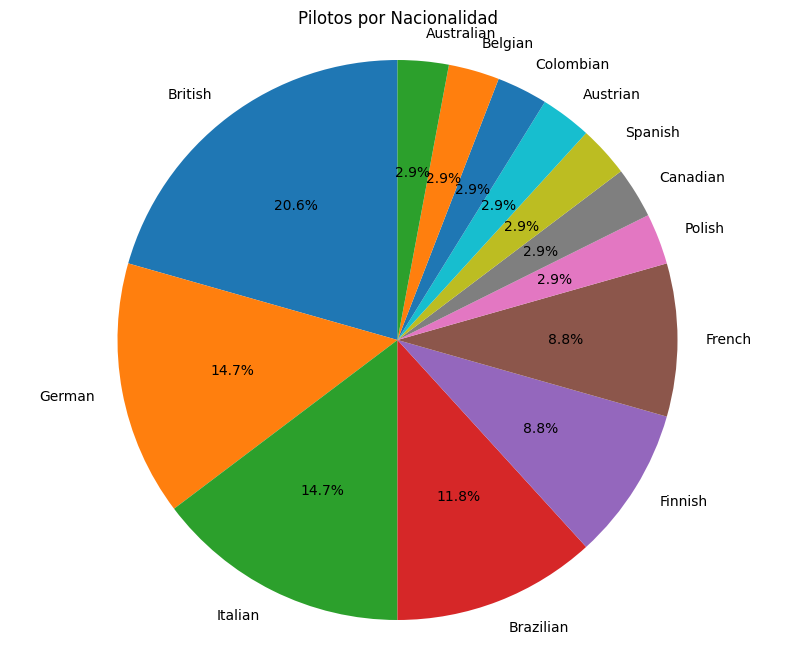

Distribución:
British: 7 pilotos
German: 5 pilotos
Italian: 5 pilotos
Brazilian: 4 pilotos
Finnish: 3 pilotos
French: 3 pilotos
Polish: 1 pilotos
Canadian: 1 pilotos
Spanish: 1 pilotos
Austrian: 1 pilotos
Colombian: 1 pilotos
Belgian: 1 pilotos
Australian: 1 pilotos


In [60]:
plt.figure(figsize=(10, 8))

nationality_counts = drivers_wins['nationality'].value_counts()
plt.pie(nationality_counts.values,
        labels=nationality_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Pilotos por Nacionalidad')
plt.axis('equal')
plt.show()

# Mostrar datos básicos
print("Distribución:")
for nationality, count in nationality_counts.items():
    print(f"{nationality}: {count} pilotos")

#Número de victorias por piloto

Hamilton y Schumacher tienen una diferencia de 199 vistorias entre ellos y una diferencia de mas 526 victorias y 327 victorias respectivamente con los demas pilotos.

In [62]:
drivers_number_wins.head()

,forename,surname,nationality,total_victorias
0,Lewis,Hamilton,British,1043
1,Michael,Schumacher,German,844
2,Sebastian,Vettel,German,517
3,Alain,Prost,French,472
4,Ayrton,Senna,Brazilian,394


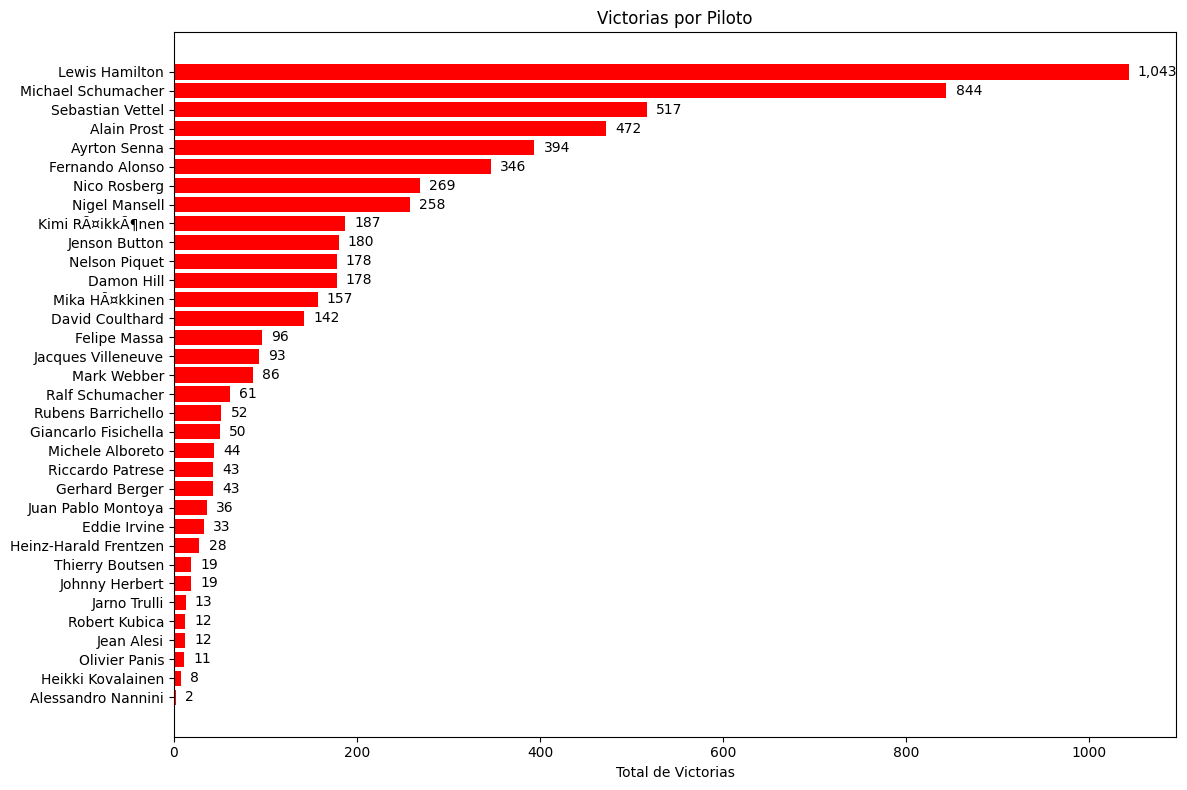

In [67]:
plt.figure(figsize=(12, 8))

drivers_number_wins['piloto'] = drivers_number_wins['forename'] + ' ' + drivers_number_wins['surname']

driver_sorted = drivers_number_wins.sort_values('total_victorias', ascending=True)
plt.barh(driver_sorted['piloto'], driver_sorted['total_victorias'], color='red')

plt.title('Victorias por Piloto')
plt.xlabel('Total de Victorias')

for i, (piloto, victorias) in enumerate(zip(driver_sorted['piloto'], driver_sorted['total_victorias'])):
    plt.text(victorias + 10, i, f'{victorias:,}', va='center')

plt.tight_layout()
plt.show()

# Número total de carreras por circuito
El Autodronomo Nazionale di Monza, Circuit de Monaco y Silverstone Circuit se han usado mas de 100 veces en los 64 años de los registros.

In [69]:
races_per_circuit.head()

,circuito,country,total_carreras
0,Autodromo Nazionale di Monza,Italy,135
1,Circuit de Monaco,Monaco,128
2,Silverstone Circuit,UK,106
3,Circuit de Spa-Francorchamps,Belgium,98
4,NÃ¼rburgring,Germany,77


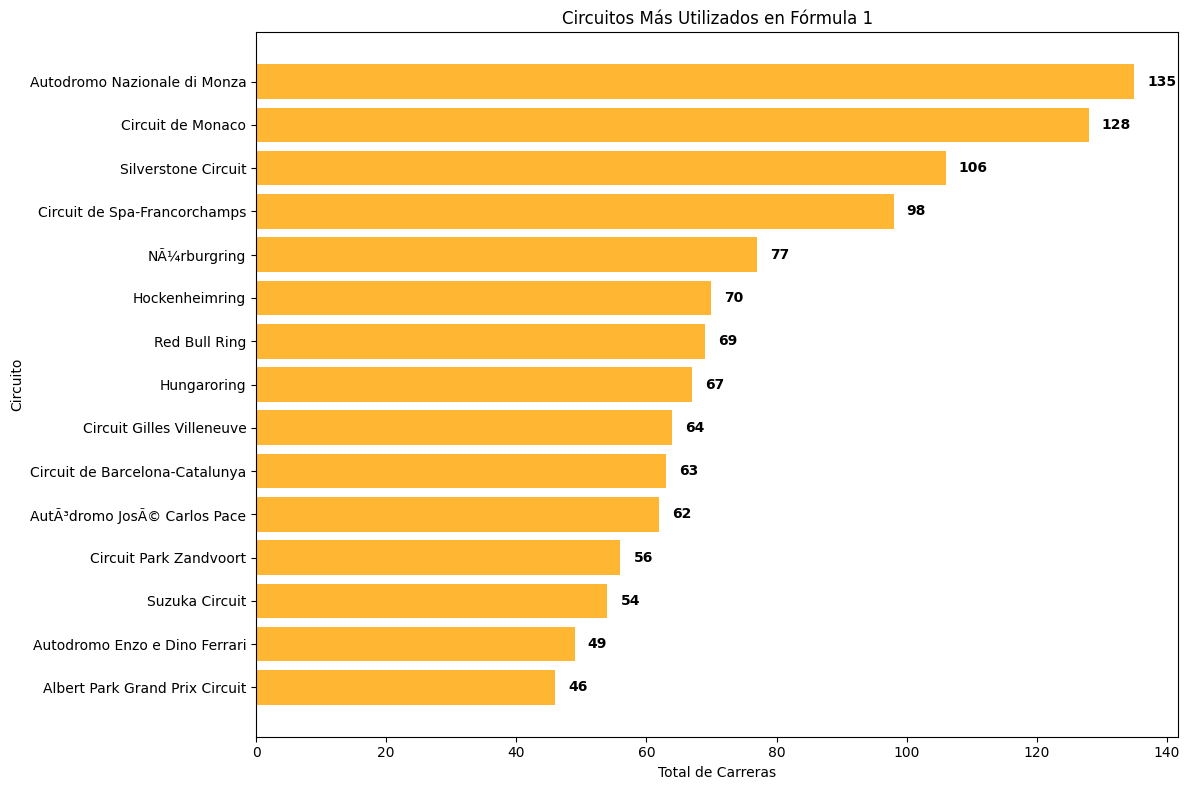

In [75]:
plt.figure(figsize=(12, 8))

top_circuitos = races_per_circuit.nlargest(15, 'total_carreras').sort_values('total_carreras', ascending=True)

plt.barh(top_circuitos['circuito'], top_circuitos['total_carreras'],
         color='orange', alpha=0.8)

plt.title('Circuitos Más Utilizados en Fórmula 1')
plt.xlabel('Total de Carreras')
plt.ylabel('Circuito')

for i, (circuito, carreras) in enumerate(zip(top_circuitos['circuito'], top_circuitos['total_carreras'])):
    plt.text(carreras + 2, i, f'{carreras}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Piloto, constructor y la posición final obtenida en carreras donde la posición fue 1.
Felipe Massa y Lewis Hamilton como los pilotos más ganadores.

Ferrari como el constructor dominante

McLaren como fuerte competidor

In [77]:
drivers_first_place.head()

,forename,piloto_completo,constructor,posicion_final
0,Lewis,Hamilton,McLaren,1
1,Kimi,RÃ¤ikkÃ¶nen,Ferrari,1
2,Felipe,Massa,Ferrari,1
3,Kimi,RÃ¤ikkÃ¶nen,Ferrari,1
4,Felipe,Massa,Ferrari,1


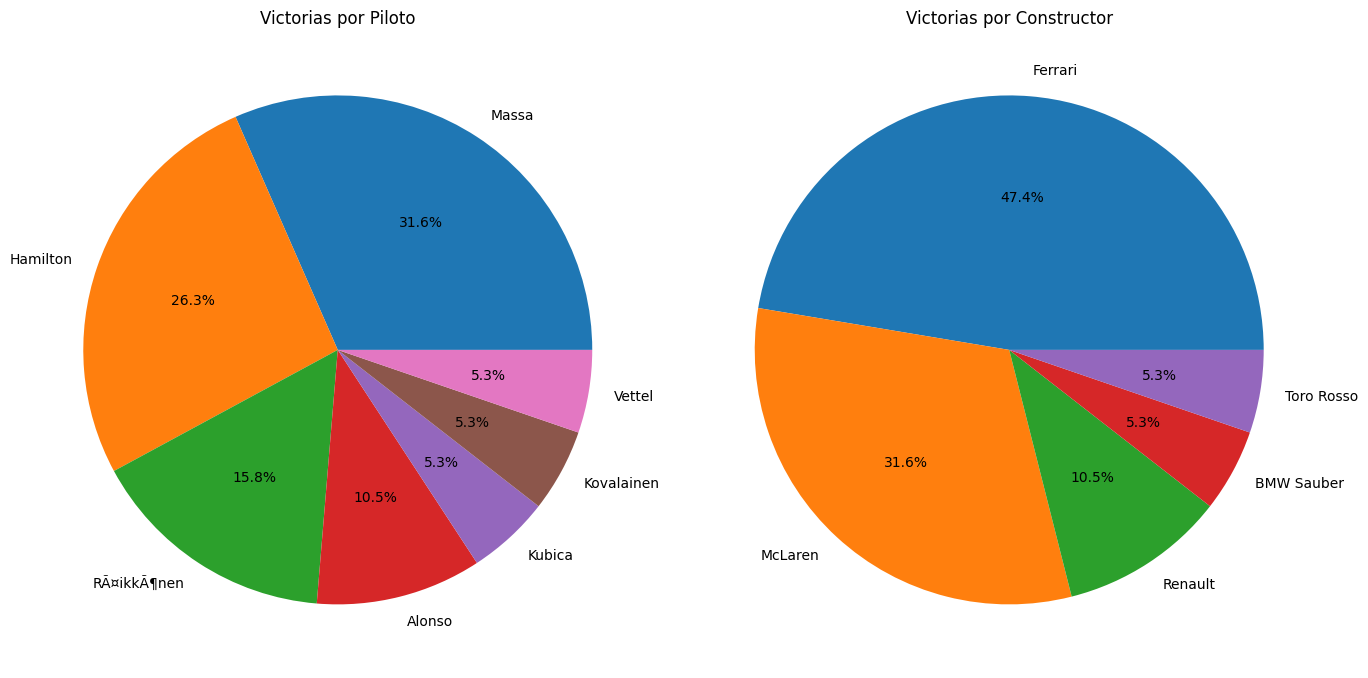

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

victorias_piloto = drivers_first_place['piloto_completo'].value_counts()
ax1.pie(victorias_piloto.values, labels=victorias_piloto.index, autopct='%1.1f%%')
ax1.set_title('Victorias por Piloto')

victorias_constructor = drivers_first_place['constructor'].value_counts()
ax2.pie(victorias_constructor.values, labels=victorias_constructor.index, autopct='%1.1f%%')
ax2.set_title('Victorias por Constructor')

plt.tight_layout()
plt.show()

Felipe Massa, Lewis Hamilton y Kimi Räikkönen son los unicos pilotos cuyo número total de victorias es mayor que el promedio de victorias de todos los pilotos en los cuales terminaron en primer lugar.



In [79]:
results_mean_victory

,piloto_completo,total_victorias,promedio_general
0,Massa,6,2.7143
1,Hamilton,5,2.7143
2,RÃ¤ikkÃ¶nen,3,2.7143


# Constructores que han obtenido el mayor número de victorias

In [14]:
constructors_victories.head()

,constructor_name,victories
0,Ferrari,9
1,McLaren,6
2,Renault,2
3,BMW Sauber,1
4,Toro Rosso,1


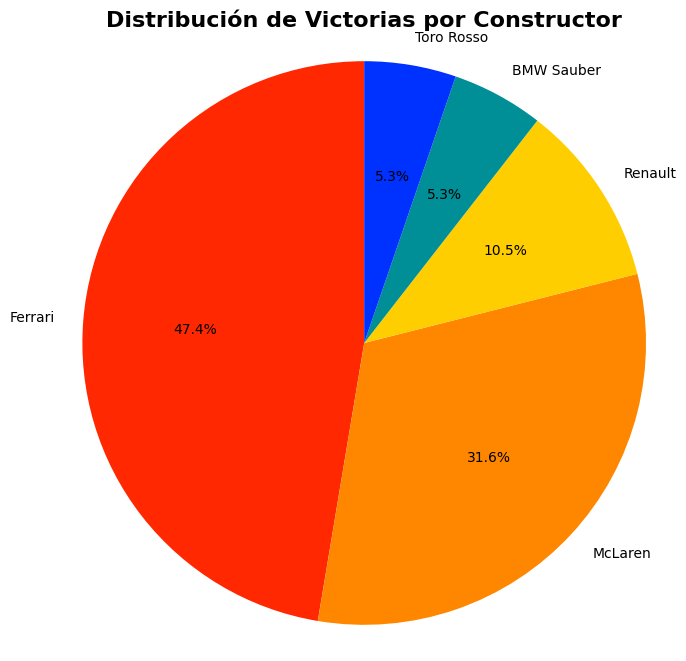

In [ ]:
plt.figure(figsize=(8, 8))
colors = ['#FF2800', '#FF8700', '#FFCE00', '#008E97', '#0032FF']

plt.pie(constructors_victories['victories'], labels=constructors_victories['constructor_name'], colors=colors,autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Victorias por Constructor', fontsize=16, fontweight='bold')
plt.axis('equal')

plt.show()